In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, make_interp_spline

In [2]:
df = pd.read_csv('./cell_D_RPT0.csv')
Q_total = df['Charge (mA.h)'].max() 
print(f"Total measured capacity: {Q_total:.2f} mAh")

Total measured capacity: 4846.04 mAh


In [3]:
# 2. Calculate State of Charge (SOC)
# Formula: SOC = 1 - (Discharged Capacity / Total Capacity)
df['SOC'] = 1.0 - (df['Charge (mA.h)'] / Q_total)

In [4]:
# 3. Create the OCV-SOC Lookup Model
# We use scipy's interp1d to create a callable function.
soc_array = df['SOC'].values[::-1]
ocv_array = df['Voltage (V)'].values[::-1]

In [5]:
# This is the parametric model! 
ocv_model = interp1d(soc_array, ocv_array, kind='linear', fill_value="extrapolate")

In [6]:
# --- Testing the Model ---
# Let's see what the Open Circuit Voltage is at 50% and 80% SOC
print(f"OCV at 5% SOC: {ocv_model(0.05):.4f} V")
print(f"OCV at 80% SOC: {ocv_model(0.80):.4f} V")

OCV at 5% SOC: 3.0246 V
OCV at 80% SOC: 3.9843 V


In [7]:
# Save the SOC and OCV arrays to a clean CSV
df_export = pd.DataFrame({'SOC': soc_array, 'OCV': ocv_array})
df_export.to_csv('ocv_soc_lookup.csv', index=False)

In [8]:
df_pul = pd.read_csv('cell D_RPT1_Hybrid CC-Pulse 0.5C discharge data.csv')

In [9]:
from scipy.optimize import curve_fit

In [10]:
# Ensure time is zeroed for easier plotting and fitting
df_pul['Time (s)'] = df_pul['Time (s)'] - df_pul['Time (s)'].iloc[0]
df_pul

,Time (s),Voltage (V),Current (mA),Charge (mA.h),Temperature (degC)
0,0.00000,4.116698,-2498.9004,0.001388,25.466873
1,0.10000,4.107167,-2499.2939,0.070817,25.632956
2,0.20000,4.105711,-2498.7036,0.140250,25.838579
3,0.30000,4.104923,-2499.2939,0.209681,25.403606
4,0.40000,4.104253,-2500.2778,0.279114,25.411512
...,...,...,...,...,...
65962,6563.40833,2.500976,-2498.9004,4556.757367,30.670746
65963,6563.50833,2.500425,-2499.6875,4556.826799,30.496754
65964,6563.60833,2.500070,-2498.7036,4556.896231,30.544209
65965,6563.61233,2.499991,-2499.8843,4556.899009,30.544209


In [11]:
# 2. Automatically Detect the First Pulse Edge
# We look for a massive instantaneous drop in current (e.g., a change of more than 1000 mA)
df_pul['dI'] = df_pul['Current (mA)'].diff()
# Find the index of the first major pulse activation
pulse_start_idx = df_pul[df_pul['dI'] < -1000].index[0]

In [12]:
# 3. Calculate Ohmic Resistance (R0)
# Extract values just before the pulse and instantly after
t_before = df_pul['Time (s)'].iloc[pulse_start_idx - 1]
V_before = df_pul['Voltage (V)'].iloc[pulse_start_idx - 1]
I_before = df_pul['Current (mA)'].iloc[pulse_start_idx - 1] / 1000.0  # Convert to Amps

t_instant = df_pul['Time (s)'].iloc[pulse_start_idx + 1]
V_instant = df_pul['Voltage (V)'].iloc[pulse_start_idx + 1]
I_instant = df_pul['Current (mA)'].iloc[pulse_start_idx + 1] / 1000.0  # Convert to Amps

delta_V = V_before - V_instant
delta_I = abs(I_instant - I_before) # Magnitude of the pulse step

R0 = delta_V / delta_I
print(f"Calculated R0 (Ohmic Resistance): {R0:.5f} Ohms")

Calculated R0 (Ohmic Resistance): 0.02920 Ohms


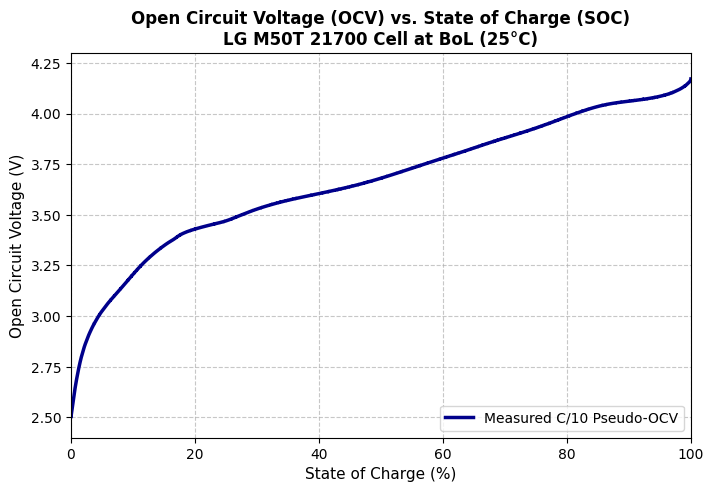

Plot saved as 'OCV_SOC_Curve.png'.


In [13]:
# Create a clean, well-proportioned figure for the technical report
plt.figure(figsize=(8, 5))

# Plot the curve directly from your df_export dataframe
# Multiplying SOC by 100 makes the x-axis a clean percentage (0 to 100%)
plt.plot(df_export['SOC'] * 100, df_export['OCV'], color='darkblue', linewidth=2.5, label='Measured C/10 Pseudo-OCV')

# Add professional formatting
plt.title('Open Circuit Voltage (OCV) vs. State of Charge (SOC)\nLG M50T 21700 Cell at BoL (25°C)', 
          fontsize=12, fontweight='bold')
plt.xlabel('State of Charge (%)', fontsize=11)
plt.ylabel('Open Circuit Voltage (V)', fontsize=11)

# Setting strict limits based on the 2.5V - 4.2V operating window of the cell
plt.xlim(0, 100)
plt.ylim(2.4, 4.3)

# Add a subtle grid for readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right', fontsize=10)

# Saved a high-resolution image for Gokul to drop into the PDF
plt.savefig('OCV_SOC_Curve.png', dpi=300, bbox_inches='tight')

# Display the plot in your notebook
plt.show()

print("Plot saved as 'OCV_SOC_Curve.png'.")

Calculated R1 (Polarization Resistance): 0.01201 Ohms
Calculated C1 (Capacitance): 990.29 Farads
Time Constant (Tau): 11.89 seconds


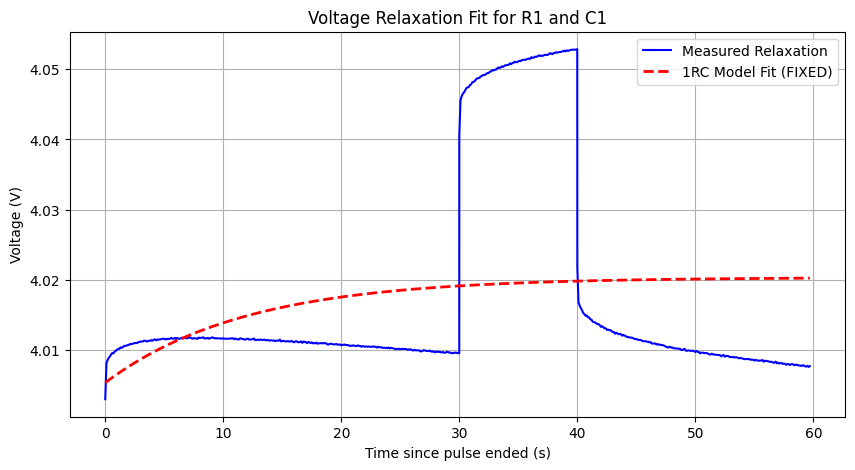

In [14]:
from scipy.optimize import curve_fit

# Extract R1 and C1 via Bounded Curve Fitting
# Slice the relaxation phase data
pulse_end_idx = df_pul[(df_pul.index > pulse_start_idx) & (df_pul['dI'] > 1000)].index[0]
relax_data = df_pul.iloc[pulse_end_idx : pulse_end_idx + 600] 
t_relax = relax_data['Time (s)'].values - relax_data['Time (s)'].values[0]
V_relax = relax_data['Voltage (V)'].values

# Define the relaxation function (Voltage curves UP to a steady state)
def relaxation_curve(t, v_steady, v_drop, tau):
    return v_steady - v_drop * np.exp(-t / tau)

# Dynamic Initial Guesses based on the specific data slice
v_steady_guess = V_relax[-1]                 # ~4.012 V
v_drop_guess = V_relax[-1] - V_relax[0]      # ~0.009 V difference
tau_guess = 10.0                             # Assume ~10 second time constant

# Forcing the optimizer to stay within realistic physical bounds
lower_bounds = [v_steady_guess - 0.05, 0.0, 1]
upper_bounds = [v_steady_guess + 0.05, 0.5, 100.0]

# Running the bounded fit
popt, pcov = curve_fit(
    relaxation_curve, 
    t_relax, 
    V_relax, 
    p0=[v_steady_guess, v_drop_guess, tau_guess],
    bounds=(lower_bounds, upper_bounds)
)

v_steady_fit, V_drop_R1_fit, tau_fit = popt

# Calculate final R1 and C1
R1 = V_drop_R1_fit / delta_I
C1 = tau_fit / R1
print(f"Calculated R1 (Polarization Resistance): {R1:.5f} Ohms")
print(f"Calculated C1 (Capacitance): {C1:.2f} Farads")
print(f"Time Constant (Tau): {tau_fit:.2f} seconds")

# 5. Plotting the fixed result
plt.figure(figsize=(10, 5))
plt.plot(t_relax, V_relax, 'b-', label='Measured Relaxation')
plt.plot(t_relax, relaxation_curve(t_relax, *popt), 'r--', linewidth=2, label='1RC Model Fit (FIXED)')
plt.title('Voltage Relaxation Fit for R1 and C1')
plt.xlabel('Time since pulse ended (s)')
plt.ylabel('Voltage (V)')
plt.legend()
plt.grid(True)
plt.show()

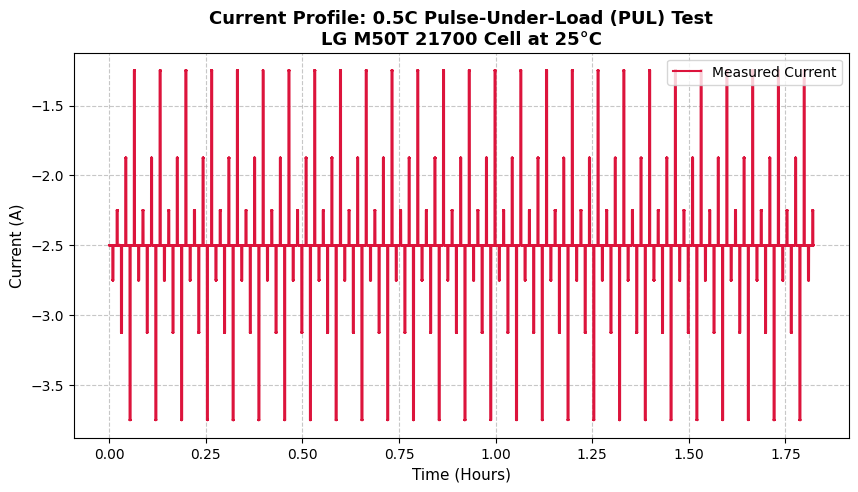

Plot saved successfully as 'Current_vs_Time_Profile.png'.


In [15]:
# Ensure this file is in the same directory as your script, or provide the full path
file_path = "cell D_RPT1_Hybrid CC-Pulse 0.5C discharge data.csv"

df_pulse = pd.read_csv(file_path)

# Zero the time array so the plot starts exactly at t = 0 seconds
time_seconds = df_pulse['Time (s)'].values - df_pulse['Time (s)'].values[0]

# Convert the time to hours for a cleaner x-axis (optional, but recommended for long tests)
time_hours = time_seconds / 3600.0

# Extract the current. Cyclers often record discharge current as negative values in milliamperes (mA).
# We divide by 1000 to convert it to standard Amperes (A).
current_amps = df_pulse['Current (mA)'].values / 1000.0

# --- Generate the  Plot ---
plt.figure(figsize=(10, 5))

# Plot the data using a distinct color and line width
plt.plot(time_hours, current_amps, color='crimson', linewidth=1.5, label='Measured Current')

# Add comprehensive, report-ready formatting
plt.title('Current Profile: 0.5C Pulse-Under-Load (PUL) Test\nLG M50T 21700 Cell at 25°C', 
          fontsize=13, fontweight='bold')
plt.xlabel('Time (Hours)', fontsize=11)
plt.ylabel('Current (A)', fontsize=11)

# Add a subtle grid to help estimate values visually
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

# Save a high-resolution image for your PDF report
output_filename = 'Current_vs_Time_Profile.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')

# Display the plot in your notebook/terminal
plt.show()

print(f"Plot saved successfully as '{output_filename}'.")

In [16]:
# --- 0. Load the PUL Data for EKF Validation ---
# We are using the HPPC pulse profile as our dynamic validation test
file_path = "cell D_RPT1_Hybrid CC-Pulse 0.5C discharge data.csv"
df_val = pd.read_csv(file_path)

# --- 1. Define the Arrays ---
# Zero the time array
time_array = df_val['Time (s)'].values - df_val['Time (s)'].values[0]

# Extract current and convert mA to Amps
current_array = df_val['Current (mA)'].values / 1000.0 

# Extract the true measured voltage
voltage_measured = df_val['Voltage (V)'].values

print(f"Loaded {len(time_array)} PUL data points for EKF validation.")

Loaded 65967 PUL data points for EKF validation.


In [17]:
# --- Load Your Established Parameters ---
# Nominal capacity in Amp-seconds
Q_total_As = 4.846 * 3600
tau = R1 * C1

# --- Initialize EKF Matrices ---
# State vector x = [SOC, V1]
x_est = np.array([[1.0],   # Starting at 100% SOC
                  [0.0]])  # Initial polarization voltage is 0

# Covariance matrix P (Initial uncertainty)
P = np.array([[1e-4, 0],
              [0, 1e-4]])

# Q: Process noise (Trust in the model vs current integration)
Q_noise = np.array([[1e-6, 0],
                    [0, 1e-5]])

# R: Measurement noise (Trust in the voltage sensor)
R_noise = np.array([[1e-3]])

# --- 3. Run the EKF Loop ---
# We use the arrays from your previous current plotting script:
# time_seconds, current_amps, and df_pulse['Voltage (V)'].values
voltage_measured = df_pulse['Voltage (V)'].values

soc_estimates = []

print("Running EKF Loop...")
for k in range(1, len(time_seconds)):
    dt = time_seconds[k] - time_seconds[k-1]
    
    # Sign convention: EKF usually expects positive current for discharge
    I_k = abs(current_amps[k-1]) 
    
    # --- PREDICTION ---
    A = np.array([[1, 0],
                  [0, np.exp(-dt / tau)]])
    
    B = np.array([[-dt / Q_total_As],
                  [R1 * (1 - np.exp(-dt / tau))]])
    
    x_pred = A @ x_est + B * I_k
    P_pred = A @ P @ A.T + Q_noise
    
    # Ensure SOC stays within bounds for the OCV lookup
    soc_pred_clipped = np.clip(x_pred[0, 0], 0.001, 0.999)
    v1_pred = x_pred[1, 0]
    
    # Expected voltage
    # Note: If discharge current is positive, terminal voltage drops: V = OCV - V1 - I*R0
    V_pred = ocv_model(soc_pred_clipped) - v1_pred - (I_k * R0)
    
    # --- UPDATE ---
    # Calculate OCV slope dynamically
    delta_soc = 1e-4
    dOCV_dSOC = (ocv_model(soc_pred_clipped + delta_soc) - ocv_model(soc_pred_clipped - delta_soc)) / (2 * delta_soc)
    
    C_mat = np.array([[dOCV_dSOC, -1]])
    
    S = C_mat @ P_pred @ C_mat.T + R_noise
    K = P_pred @ C_mat.T @ np.linalg.inv(S)
    
    y_tilde = voltage_measured[k] - V_pred
    
    x_est = x_pred + K * y_tilde
    P = (np.eye(2) - K @ C_mat) @ P_pred
    
    soc_estimates.append(x_est[0, 0])

# --- 4. Evaluate Accuracy ---
# Calculate True SOC via Coulomb Counting
dt_array = np.diff(time_seconds, prepend=time_seconds[0])
charge_removed_As = np.cumsum(abs(current_amps) * dt_array)
true_soc = 1.0 - (charge_removed_As / Q_total_As)

# Align arrays (EKF ran from index 1)
ekf_soc_array = np.array(soc_estimates)
true_soc_aligned = true_soc[1:] 

# Calculate Metrics
soc_error_percent = (ekf_soc_array - true_soc_aligned) * 100
rmse_soc = np.sqrt(np.mean(soc_error_percent**2))
mae_soc = np.mean(np.abs(soc_error_percent))

print(f"\n--- RESULTS ---")
print(f"Target Accuracy: ≤ 5.00% SOC Error")
print(f"Achieved RMSE: {rmse_soc:.2f}%")
print(f"Achieved MAE:  {mae_soc:.2f}%")

Running EKF Loop...

--- RESULTS ---
Target Accuracy: ≤ 5.00% SOC Error
Achieved RMSE: 2.17%
Achieved MAE:  1.70%
